# AI 221 Assignment 11: Weak and Ensemble Learning

<b>Description:</b> This notebook demonstrates classification on students' dropout and academic success, particularly demonstrating weak and ensemble learning techniques such as kNN (weak learner), Random Forest (an ensemble learning method), and boosted trees (particularly XGBoost - an ensemble learning method). Dataset used is the Students' Dropout and Academic Success Dataset that can be found on https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success.
<br>
<br>
<b>Author:</b> Adrian Josele G. Quional
<br>
<b>Submitted to:</b> Dr. Jon Dewitt E. Dalisay
<br>
<b>Semester/Year:</b> 2nd Semester/2024-2025

In [1]:
# imports

# UCI repo
# Note: Before importing make sure to install first the UCI ML repo (if the dataset is not manually downloaded) using the command pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 

# for plotting
import seaborn as sns
import matplotlib.pyplot as plt

# for dataset manipulation and computation
import pandas as pd
import numpy as np

# scikit-learn for data processing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# scikit-learn for classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# scikit-learn for hyperparameter search
from sklearn.model_selection import StratifiedKFold
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

# scikit-learn for evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay

# to time each model fitting
import time

## Data fetching and preliminary data checks

This section does the usual preliminary check on the data. Beyond this, extensive EDA is not conducted as it has been done already in the previous assignments.

In [2]:
# fetching the dataset 
student = fetch_ucirepo(id=697) # alternatively: fetch_ucirepo(name="Predict Students' Dropout and Academic Success")
student_df = student.data.original

# temporarily set the option to display all columns
with pd.option_context('display.max_columns', None):
    # checking the data
    print(student_df.head())

   Marital Status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                           122.0     

In [3]:
# checking info of the DataFrame
student_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

There are 36 features, all numerical. The target is either "Dropout" or "Graduate".

In [4]:
# checking descriptive statistics for each column
student_df.describe(include="all")

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


In [5]:
# checking missing values
print(f"Missing values in the DataFrame: \n{student_df.isnull().sum()}\n")

Missing values in the DataFrame: 
Marital Status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder            

It is evident that there are no missing values (as also explicitly mentioned in the dataset website).

## Data Processing

This section processes the data: standardizing, encoding, and splitting.

In [6]:
# manually separating feature columns into continuous, categorical, ordinal, and binary columns
# different transformations are to be done per type
# checking the variables table enabled the separation of these columns

continuous_cols = ["Previous qualification (grade)", "Admission grade", "Age at enrollment", "Curricular units 1st sem (credited)", 
                   "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)",
                   "Curricular units 1st sem (grade)", "Curricular units 1st sem (without evaluations)", "Curricular units 2nd sem (credited)", 
                   "Curricular units 2nd sem (enrolled)", "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)", 
                   "Curricular units 2nd sem (grade)", "Curricular units 2nd sem (without evaluations)", "Unemployment rate", "Inflation rate", "GDP"]

ordinal_cols = ["Application order", "Previous qualification", "Mother's qualification", "Father's qualification"]

categorical_cols = ["Marital Status", "Application mode", "Course", "Nacionality", "Mother's occupation", "Father's occupation"]

binary_cols = ["Daytime/evening attendance", "Displaced", "Educational special needs", "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder", 
               "International"]

# creating separate DataFrames (with the Target) consisting of the different feature types
student_continuous_df = pd.concat([student_df[continuous_cols], student_df["Target"]], axis=1)
student_ordinal_df = pd.concat([student_df[ordinal_cols], student_df["Target"]], axis=1)
student_categorical_df = pd.concat([student_df[categorical_cols], student_df["Target"]], axis=1)
student_binary_df = pd.concat([student_df[binary_cols], student_df["Target"]], axis=1)

# isolating the features and target
X_cont = student_continuous_df.drop("Target", axis=1).to_numpy()
X_ord = student_ordinal_df.drop("Target", axis=1).to_numpy()
X_cat = student_categorical_df.drop("Target", axis=1).to_numpy() 
X_bin = student_binary_df.drop("Target", axis=1).to_numpy()

y = student_continuous_df["Target"].to_numpy()

# defining LabelEncoder for target labels
label_encoder = LabelEncoder()

# encoding the target labels (y)
y_encoded = label_encoder.fit_transform(y)

# defining the class labels
class_labels = label_encoder.classes_  # getting the original labels ['Dropout', 'Enrolled', 'Graduate'] for later plotting of the confusion matrices

# defining transformers for preprocessing 
# standardization for continuous/ordinal, one-hot encoding for categorical
continuous_scaler = StandardScaler()  # standardizing continuous features
ordinal_scaler = StandardScaler()  # standardizing ordinal features
categorical_encoder = OneHotEncoder(handle_unknown='ignore') # one-hot encoding categories

X_cont_scaled = continuous_scaler.fit_transform(X_cont)
X_ord_scaled = ordinal_scaler.fit_transform(X_ord)
X_cat_encoded = categorical_encoder.fit_transform(X_cat).toarray()

# concatenating all features into one NumPy array
X_combined = np.hstack([X_cont_scaled, X_ord_scaled, X_cat_encoded, X_bin])

# checking the result of the transformations
print("Combined (and standardized) features array:")
print(X_combined)
print()
print("Encoded target array:")
print(y_encoded) # it's ok not to label encode the targets since SVC can handle strings
print("=====\n")

# checking first row of features
print(f"First row of features (Length: {len(X_combined[0])}):")
print(X_combined[0])

Combined (and standardized) features array:
[[-0.80484126  0.02222877 -0.43036282 ...  1.          0.
   0.        ]
 [ 2.07681932  1.07192614 -0.56216796 ...  1.          0.
   0.        ]
 [-0.80484126 -0.15041883 -0.56216796 ...  1.          0.
   0.        ]
 ...
 [ 1.62182028  1.5553394   0.8876885  ...  0.          1.
   0.        ]
 [ 3.59348278  1.85229326 -0.43036282 ...  0.          1.
   0.        ]
 [ 1.47015393  1.727987   -0.16675256 ...  0.          0.
   1.        ]]

Encoded target array:
[0 2 0 ... 0 2 2]
=====

First row of features (Length: 170):
[-0.80484126  0.02222877 -0.43036282 -0.30081306 -2.52855964 -1.98606822
 -1.52125739 -2.19710239 -0.19927303 -0.28244231 -2.83833657 -2.04262989
 -1.47152688 -1.96348862 -0.19944099 -0.28763846  0.12438647  0.76576084
  2.49089589 -0.35023049 -0.03601818 -0.66977812  1.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          1.
  0.         

In [7]:
# splitting into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_encoded, test_size=0.3, stratify=y, random_state=6)

# separating preprocessed continuous features from the other columns (for conduct of PCA later)
X_train_cont = X_train[:, :X_cont.shape[1]]  # selecting only continuous columns
X_test_cont = X_test[:, :X_cont.shape[1]]  # selecting only continuous columns
X_train_ord_cat_bin = X_train[:, X_cont.shape[1]:]  # remaining columns
X_test_ord_cat_bin = X_test[:, X_cont.shape[1]:]  # remaining columns

## k-Nearest Neighbors (kNN) + PCA

This section performs kNN classification on the dataset. Before implementing the method though, PCA is conducted first to reduce the dimensions. In terms of hyperparameter optimization, a hard-coded "grid search" is conducted by looping over a list of the number of PCA components and a list of neighbors. 

PCA: 5, k: 3 → Accuracy: 0.6355 | Time to train: 0.00098 secs, Time to predict: 0.30436 secs
PCA: 5, k: 5 → Accuracy: 0.6431 | Time to train: 0.00102 secs, Time to predict: 0.08613 secs
PCA: 5, k: 7 → Accuracy: 0.6679 | Time to train: 0.00098 secs, Time to predict: 0.07200 secs
PCA: 5, k: 9 → Accuracy: 0.6694 | Time to train: 0.00119 secs, Time to predict: 0.07116 secs
PCA: 10, k: 3 → Accuracy: 0.6559 | Time to train: 0.00171 secs, Time to predict: 0.06916 secs
PCA: 10, k: 5 → Accuracy: 0.6837 | Time to train: 0.00141 secs, Time to predict: 0.09465 secs
PCA: 10, k: 7 → Accuracy: 0.6943 | Time to train: 0.00111 secs, Time to predict: 0.08922 secs
PCA: 10, k: 9 → Accuracy: 0.6943 | Time to train: 0.00183 secs, Time to predict: 0.08302 secs
PCA: 15, k: 3 → Accuracy: 0.6694 | Time to train: 0.00185 secs, Time to predict: 0.07763 secs
PCA: 15, k: 5 → Accuracy: 0.6875 | Time to train: 0.00097 secs, Time to predict: 0.07461 secs
PCA: 15, k: 7 → Accuracy: 0.6980 | Time to train: 0.00130 secs, 

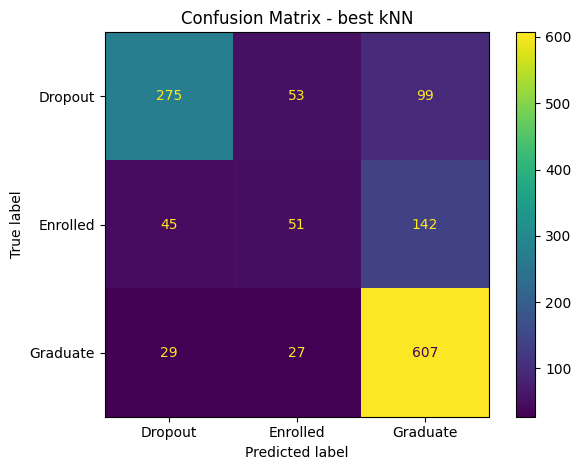

In [8]:
# defining hyperparameter grid
# to ensure we're using only values that PCA can handle
max_n_components = min(X_train_cont.shape[0], X_train_cont.shape[1])
n_components_list = [n for n in [5, 10, 15, 20, 25] if n <= max_n_components]
n_neighbors_list = [3, 5, 7, 9]

best_score = 0
best_params = {}
results = []

# grid search over PCA + kNN
for n_comp in n_components_list:
    try:
        pca = PCA(n_components=n_comp)
        X_train_pca = pca.fit_transform(X_train_cont)
        X_test_pca = pca.transform(X_test_cont)
    except ValueError as e:
        print(f"Skipping n_components={n_comp}: {e}")
        continue

    X_train_final = np.hstack((X_train_pca, X_train_ord_cat_bin))
    X_test_final = np.hstack((X_test_pca, X_test_ord_cat_bin))

    for k in n_neighbors_list:
        knn = KNeighborsClassifier(n_neighbors=k)

        start_time_fit = time.time() # start timing kNN fit
        knn.fit(X_train_final, y_train)
        end_time_fit = time.time() # end timing kNN fit

        start_time_pred = time.time() # start timing kNN predict
        y_pred = knn.predict(X_test_final)
        end_time_pred = time.time() # end timing kNN predict

        acc = accuracy_score(y_test, y_pred)
        results.append((n_comp, k, acc))

        print(f"PCA: {n_comp}, k: {k} → Accuracy: {acc:.4f} | Time to train: {end_time_fit - start_time_fit:.5f} secs, "
                f"Time to predict: {end_time_pred - start_time_pred:.5f} secs")
        if acc > best_score:
            best_score = acc
            best_params = {'n_components': n_comp, 'n_neighbors': k}
            best_y_pred = y_pred

# evaluating the model
print("\n✅ Best Parameters:", best_params)
print(f"✅ Best Accuracy: {best_score:.4f}")
print("\n📄 Classification Report:")
print(classification_report(y_test, best_y_pred, target_names=class_labels))

# confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, best_y_pred, cmap="viridis", display_labels=class_labels)
plt.title("Confusion Matrix - best kNN")
plt.tight_layout()
plt.show()

The best kNN model found is one with `n_neighbors` of 9 and, since training is coupled with dimensionality reduction, `n_components` of 15. The model achieved a test accuracy of 70%. In terms of time, kNN is quite fast in terms of training. However, in terms of predicting, it is evident that it definitely takes a long time. This is expected since, during training, kNN doesn’t really "learn" — it just stores the data. For prediction, kNN has to compute the distance from the test point to every training sample to find the nearest neighbors; therefore, it's longer than training.

## Random Forest

This section performs classification using Random Forest. Training and test data used is the original ones obtained via `train_test_split`, not the reduced data via PCA since Random Forest can handle raw and uncorrelated features well. Hyperparameter optimization is done via random search.

Fitting 5 folds for each of 100 candidates, totalling 500 fits

⏱️ Time for best Random Forest model to train: 49.58 secs
⏱️ Time for best Random Forest model to predict: 0.08 secs

✅ Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': False}
✅ Best Accuracy: 0.7797

📄 Classification Report:
              precision    recall  f1-score   support

     Dropout       0.80      0.77      0.79       427
    Enrolled       0.54      0.34      0.42       238
    Graduate       0.79      0.91      0.85       663

    accuracy                           0.77      1328
   macro avg       0.71      0.68      0.68      1328
weighted avg       0.75      0.77      0.75      1328



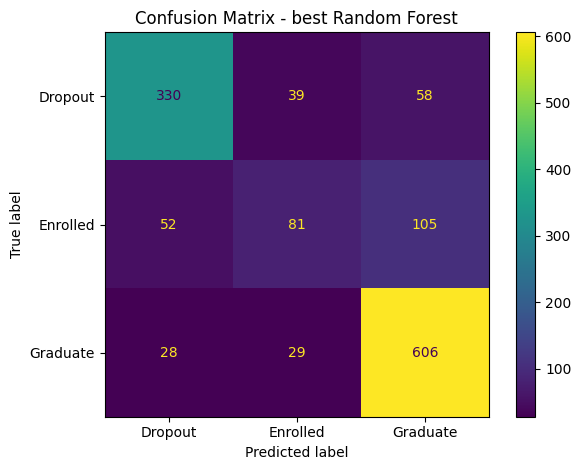

In [9]:
# defining hyperparameter grid for Random Forest
param_dist_rf = {
    'n_estimators': [50, 100, 200],   # number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # max depth of each tree
    'min_samples_split': [2, 5, 10],  # minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],    # minimum samples required to be at a leaf node
    'bootstrap': [True, False],       # whether bootstrap samples are used when building trees
}

# initializing RandomForestClassifier
rf = RandomForestClassifier(random_state=6)

# RandomizedSearchCV to tune hyperparameters
skf_5 = StratifiedKFold(n_splits=5)
random_search_rf = RandomizedSearchCV(estimator=rf, param_distributions=param_dist_rf, n_iter=100, cv=skf_5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=6)

start_time_fit = time.time() # start timing best rf training
random_search_rf.fit(X_train, y_train) # fitting the random search to the training data
end_time_fit = time.time() # end timing best rf training

# getting the best parameters and model
best_rf = random_search_rf.best_estimator_

start_time_pred = time.time() # start timing best rf prediction
y_pred = best_rf.predict(X_test) # making predictions on the test set
end_time_pred = time.time() # end timing best rf prediction

# evaluating the model
print(f"\n⏱️ Time for best Random Forest model to train: {end_time_fit - start_time_fit:.2f} secs")
print(f"⏱️ Time for best Random Forest model to predict: {end_time_pred - start_time_pred:.2f} secs")
print("\n✅ Best Parameters:", random_search_rf.best_params_)
print(f"✅ Best Accuracy: {random_search_rf.best_score_:.4f}")
print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_labels))

# confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="viridis", display_labels=class_labels)
plt.title("Confusion Matrix - best Random Forest")
plt.tight_layout()
plt.show()

The best Random Forest model found is one with `n_estimators` of 200, `min_samples_split` of 2, `min_samples_leaf`: 1, `max_depth` of 20, and `bootstrap` of False. 
The model achieved a test accuracy of 77%, higher than that of kNN. In terms of time, Random Forest is slow in terms of training but for prediction, it's blazingly fast. This is expected since Random Forest builds multiple decision trees during training. Each tree is built independently, and it involves random feature selection and bootstrapping (sampling with replacement), which makes training time-consuming, especially as the number of trees (`n_estimators`) increases. Once the Random Forest is trained, making predictions is much faster. It simply passes the data through each decision tree and aggregates the results (majority vote for classification or average for regression). This is less computationally expensive because it only involves traversing each tree, which is efficient at runtime. Therefore, Random Forest is fast during prediction while slow during training.

## XGBoost

This section performs classification using XGBoost. Like in Random Forest, training and test data used is the original ones obtained via `train_test_split`, not the reduced data via PCA since XGBoost has built-in regularization and feature sampling. Hyperparameter optimization is done via random search.

Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Time for best XGBoost model model to train: 23.47 secs
⏱️ Time for best XGBoost model model to predict: 0.00204 secs

✅ Best Parameters: {'colsample_bytree': 1.0, 'gamma': 0.2, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 120, 'subsample': 1.0}
✅ Best Accuracy: 0.7817

📄 Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.79      0.81       427
    Enrolled       0.53      0.40      0.46       238
    Graduate       0.81      0.90      0.85       663

    accuracy                           0.78      1328
   macro avg       0.72      0.70      0.71      1328
weighted avg       0.76      0.78      0.77      1328



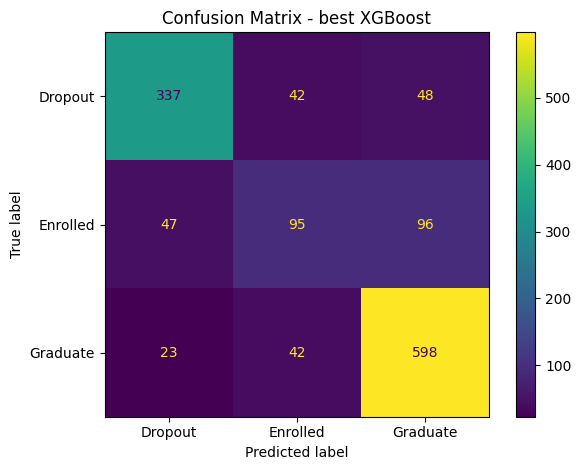

In [10]:
# defining the hyperparameter search space for RandomizedSearchCV
param_dist_xgb = {
    'n_estimators': randint(50, 201),            # number of trees in the forest
    'max_depth': [3, 5, 7, 9, 10],               # max depth of each tree
    'learning_rate': [0.001, 0.01, 0.1, 0.2],    # learning rate
    'subsample': [0.6, 0.8, 1.0],                # fraction of samples used for training each tree
    'colsample_bytree': [0.6, 0.8, 1.0],         # fraction of features used for training each tree
    'min_child_weight': randint(1, 11),          # minimum sum of instance weight (hessian) in a child
    'gamma': [0, 0.1, 0.2, 0.3]                  # minimum loss reduction required to make a further partition
}

# initializing XGBoost Classifier
xgboost_model = xgb.XGBClassifier(random_state=6, eval_metric='mlogloss')

# RandomizedSearchCV to tune hyperparameters (fewer iterations, fewer folds, less cores used, to prevent CPU overload)
skf_3 = StratifiedKFold(n_splits=3)
random_search_xgb = RandomizedSearchCV(estimator=xgboost_model, param_distributions=param_dist_xgb, n_iter=20, cv=skf_3, n_jobs=2, 
                                   verbose=1, scoring='accuracy', random_state=6)

start_time_fit = time.time() # start timing best XGBoost training
random_search_xgb.fit(X_train, y_train) # fitting the best XGBoost model to the training data
end_time_fit = time.time() # end timing best XGBoost training

# getting the best parameters and model
best_xgboost = random_search_xgb.best_estimator_

start_time_pred = time.time() # start timing best XGBoost prediction
y_pred = best_xgboost.predict(X_test) # making predictions on the test set
end_time_pred = time.time() # end timing best XGBoost prediction

# evaluating the model
print(f"\n⏱️ Time for best XGBoost model model to train: {end_time_fit - start_time_fit:.2f} secs")
print(f"⏱️ Time for best XGBoost model model to predict: {end_time_pred - start_time_pred:.5f} secs")
print("\n✅ Best Parameters:", random_search_xgb.best_params_)
print(f"✅ Best Accuracy: {random_search_xgb.best_score_:.4f}")
print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_labels))

# confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="viridis", display_labels=class_labels)
plt.title("Confusion Matrix - best XGBoost")
plt.tight_layout()
plt.show()

The best XGBoost model found is one with `colsample_bytree` of 1.0, `gamma` of 0.2, `learning_rate` of 0.2, `max_depth` of 3, `min_child_weight` of 6, `n_estimators` of 120, and `subsample` of 1.0. The model achieved a test accuracy of 78%, higher than achieved by both kNN and Random Forest. In terms of time, XGBoost definitely beat Random Forest in both training and prediction. This is expected. XGBoost is a boosting algorithm, which means it builds one tree at a time, each tree trying to correct the mistakes of the previous one. Boosting tends to be slower than bagging (like in Random Forest), but it's faster than some other complex models, especially when fine-tuned. At prediction time, XGBoost is quite efficient. Since the model is based on decision trees, prediction involves just passing the input through the trained trees, which is computationally cheap.

## Summary

* Student status classification was once again conducted, this time to primarily demonstrate the different weak and ensemble learning methods. Specifically, kNN, Random Forest, and XGBoost were implemented.
* The different techniques were compared in terms of test accuracy and training and prediction times. The table below shows the results:

    |   **Method**  | **Test Accuracy** | **Training Time (s)** | **Prediction Time (s)** |
    |:-------------:|:-----------------:|:---------------------:|:-----------------------:|
    | kNN           | 0.70              | 0.00105               | 0.08227                 |
    | Random Forest | 0.77              | 49.58                 | 0.08                    |
    | XGBoost       | 0.78              | 23.47                 | 0.00204                 |
    
* Among the three methods tested, XGBoost really stood out. It had the highest test accuracy, and beats the prediction time of both kNN and Random Forest. As for accuracy, it's not really generally that satisfactory given that it's only 78% and only one percentage point up than Random Forest. It is envisioned though that in other datasets, XGBoost would really be superior compared to other methods. As for training time, notice that kNN really has the fastest time, though this is at the expense of both accuracy and prediction time. The fast training time is expected because of the abovementioned explanation - it doesn't really "learn", rather, just stores data. If training time is a huge consideration, then kNN is a real winner. In terms of prediction time and accuracy, XGBoost is a true standout. In general, from the results, it seems that XGBoost is a production-ready method - it stands out in terms of test accuracy and prediction time. If training time is a consideration, it's also relatively fast. More so, XGBoost doesn't need dimensionality reduction as it has a built-in regularization feature.   